In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_data_reader.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'
import dutta_test.utils as utils

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_buzsaki.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    print("Fall_off:", sorted(df["Fall_off"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2400 rows from spikes\all_networks_metrics_buzsaki.csv
Columns: ['Session', 'Channel', 'Threshold', 'Fall_off', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Fall_off: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]


,Session,Channel,Threshold,Fall_off,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,PV01ai32FPGA_250611_122326,20,1.0,0.5,138,2130,31,0.060847,0.816568,0.113254,0.854589,3164,169,11.670613
1,Calb_251210_115904,15,1.0,0.5,44,2108,12,0.020446,0.785714,0.039855,6.588636,3011,56,11.571627
2,Calbai32FPGA_251003_144832,11,1.0,0.5,160,1701,33,0.085975,0.829016,0.155794,5.025000,2515,193,11.366827
3,Calb_251210_121141,15,1.0,0.5,56,1899,13,0.028645,0.811594,0.055336,1.580357,2771,69,10.848569
4,Calb_251210_122327,13,1.0,0.5,73,1852,18,0.037922,0.802198,0.072421,1.526941,2708,91,10.954382


In [3]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique(),len(df["Session"].unique()))
# df=df[~df["Session"].isin(ripple_sessions)]

['PV01ai32FPGA_250611_122326' 'Calb_251210_115904'
 'Calbai32FPGA_251003_144832' 'Calb_251210_121141' 'Calb_251210_122327'
 'Calb_251211_104316' 'Calb_251210_164150' 'Calb_251210_165332'
 'Calb_251211_110650' 'Calb_251211_105518' 'Calb_251210_162849'
 'Calb_251209_160255' 'PV01ai32FPGA_250611_115923'
 'Calbai32FPGA_251003_150055' '2025-09-23_16-17-52' '2025-09-23_15-50-26'
 '2025-09-22_17-42-27' '2025-09-24_11-34-51' '2025-09-24_16-29-07'
 '2025-09-25_11-21-53' '2025-09-22_17-55-26' '2025-09-24_10-24-40'
 '2025-09-25_16-41-14'] 23


In [4]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby([ "Threshold","Fall_off"])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


F1  Precision  Recall    TP      FP    FN
Threshold Fall_off                                              
5.0       4.5       0.711      0.710   0.676  79.0    29.0  45.0
6.0       4.0       0.701      0.655   0.700  82.0    33.0  42.0
          5.0       0.696      0.760   0.624  72.0    16.0  55.0
          4.5       0.696      0.723   0.659  76.0    25.0  48.0
7.0       4.5       0.691      0.741   0.613  68.0    17.0  53.0
...                   ...        ...     ...   ...     ...   ...
3.0       0.5       0.316      0.191   0.919  95.0   436.0   8.0
2.0       1.5       0.262      0.152   0.938  97.0   588.0   7.0
          1.0       0.192      0.107   0.924  95.0   853.0   9.0
          0.5       0.171      0.095   0.890  97.0   949.0  11.0
1.0       0.5       0.097      0.051   0.809  91.0  1757.0  19.0

[96 rows x 6 columns]

C:\Users\Pc\AppData\Local\Temp\ipykernel_21880\4022452823.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Group", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=group_order)


N=23 matched samples for statistics.
Comparing 10.0_1.0 vs 10.0_2.0:
Comparing 10.0_1.0 vs 10.0_3.0:
Comparing 10.0_1.0 vs 10.0_4.0:
Comparing 10.0_1.0 vs 10.0_5.0:
Comparing 10.0_1.0 vs 10.0_6.0:
Comparing 10.0_1.0 vs 10.0_7.0:
Comparing 10.0_1.0 vs 10.0_8.0:
Comparing 10.0_1.0 vs 2.0_1.0:
Comparing 10.0_1.0 vs 3.0_1.0:
Comparing 10.0_1.0 vs 3.0_2.0:
Comparing 10.0_1.0 vs 4.0_1.0:
Comparing 10.0_1.0 vs 4.0_2.0:
Comparing 10.0_1.0 vs 4.0_3.0:
Comparing 10.0_1.0 vs 5.0_1.0:
Comparing 10.0_1.0 vs 5.0_2.0:
Comparing 10.0_1.0 vs 5.0_3.0:
Comparing 10.0_1.0 vs 5.0_4.0:
Comparing 10.0_1.0 vs 6.0_1.0:
Comparing 10.0_1.0 vs 6.0_2.0:
Comparing 10.0_1.0 vs 6.0_3.0:
Comparing 10.0_1.0 vs 6.0_4.0:
Comparing 10.0_1.0 vs 6.0_5.0:
Comparing 10.0_1.0 vs 7.0_1.0:
Comparing 10.0_1.0 vs 7.0_2.0:
Comparing 10.0_1.0 vs 7.0_3.0:
Comparing 10.0_1.0 vs 7.0_4.0:
Comparing 10.0_1.0 vs 7.0_5.0:
Comparing 10.0_1.0 vs 7.0_6.0:
Comparing 10.0_1.0 vs 8.0_1.0:
Comparing 10.0_1.0 vs 8.0_2.0:
Comparing 10.0_1.0 vs 8.0_

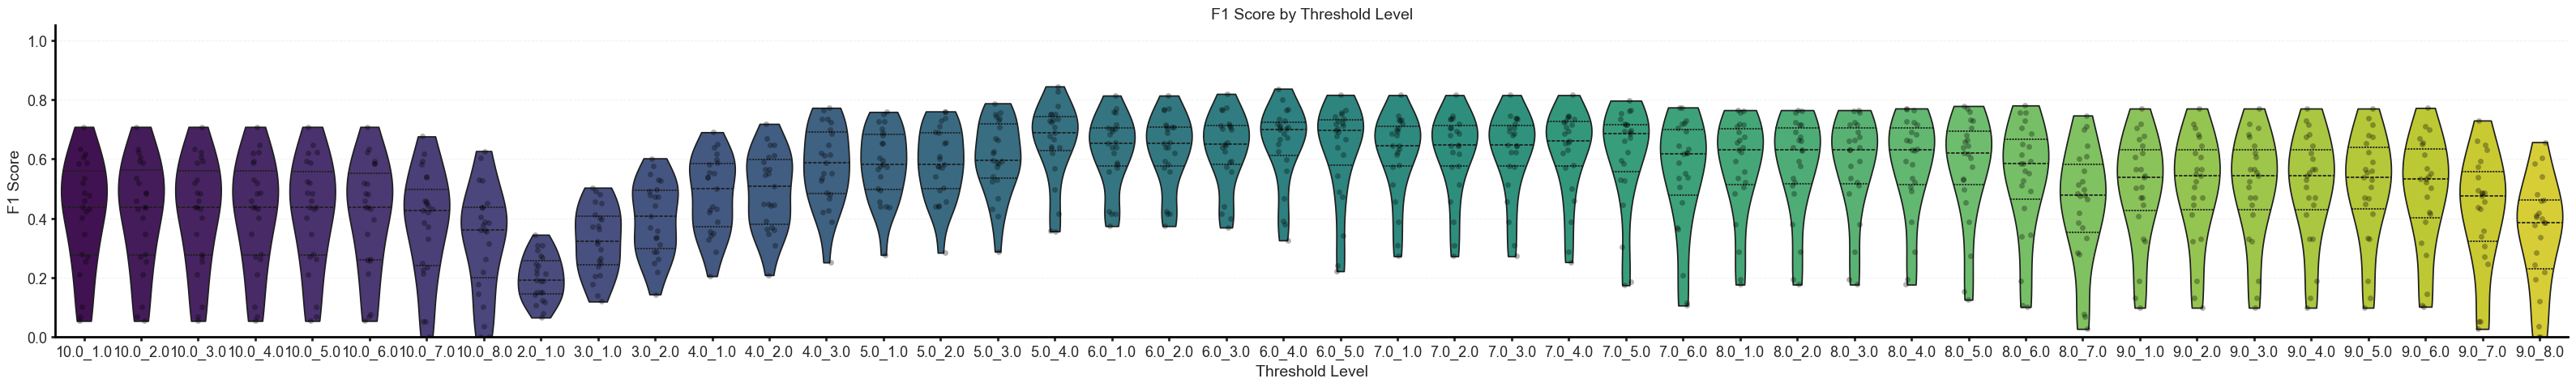

In [5]:
from snnTorch.generalization_madrid.utils import holm_bonferroni

# Define shared color palette for consistency across plots
# Get viridis colors based on number of thresholds (will be determined dynamically)
def get_threshold_colors(adapt_values):
    """Get consistent viridis colors for thresholds."""
    return sns.color_palette("viridis", len(adapt_values))

def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False,figsize=(5,6),thresholds_to_include=None,fall_offs_to_include=None):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Threshold"].unique()]
    thresholds_to_include = thresholds_to_include if thresholds_to_include is not None else sorted(df["Threshold"].unique())
    fall_offs_to_include = fall_offs_to_include if fall_offs_to_include is not None else sorted(df["Fall_off"].unique())
    mask= (df["Threshold"].isin(thresholds_to_include)) & (df["Fall_off"].isin(fall_offs_to_include))
    plot_df=df[mask].copy()
    
    plot_df["Group"] = plot_df["Threshold"].astype(str) + "_" + plot_df["Fall_off"].astype(str)
    group_order = sorted(plot_df["Group"].unique(), key=lambda x: ((x.split("_")[0]), x.split("_")[1]))
    fig, ax = plt.subplots(figsize=figsize)
    
    # Boxplot
    # sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.violinplot(x="Group", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=group_order)
    sns.stripplot(x="Group", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=group_order)
    

    pivot_cols = ["Session"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Group", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    p_values=[]
    pairs=[]
    if len(pivot) > 0:
        
        centers = range(len(group_order))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(group_order)), 2))
        for idx, (i, j) in enumerate(combinations):
            print(f"Comparing {group_order[i]} vs {group_order[j]}:")
            a1 = group_order[i]
            a2 = group_order[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                try:
                    stat, p = wilcoxon(v1, v2)
                    p_values.append(p)
                    pairs.append((a1, a2))
                except Exception as e:
                    print(f"Error comparing {a1} vs {a2}: {e}")
                
                # Stacking logic for brackets
                # h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                # print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
            
        corrected_significant, adjusted_pvals=utils.holm_bonferroni(p_values,alpha=0.05)
        for p,sig,(b1,b2) in zip(adjusted_pvals,corrected_significant,pairs):        
                print(f"{b1} vs {b2}: p={p:.4f} {sig}")          
                # utils.barplot_annotate_brackets(group_order.index(b1), group_order.index(b2), p, centers, [max_val+0.05]*len(centers), ax, fs=12, maxasterix=3)   

    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)   
   
    ax.set_title(f"{metric} Score by Threshold Level",fontsize=14)
    ax.set_ylim(0, 1.05) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    plt.show()
    return fig,ax
if 'df' in locals():
   fig,ax = plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False,figsize=(40,5), fall_offs_to_include=[1,2,3,4,5,6,7,8,9])

Precision    Recall
Group                             
10.0_1.0 0.25   0.891460  0.161942
         0.50   0.928571  0.281081
         0.75   0.968750  0.400270
10.0_2.0 0.25   0.892308  0.161942
         0.50   0.928571  0.284024

Found optimal threshold, highlighting in red
Found reference threshold, highlighting in blue


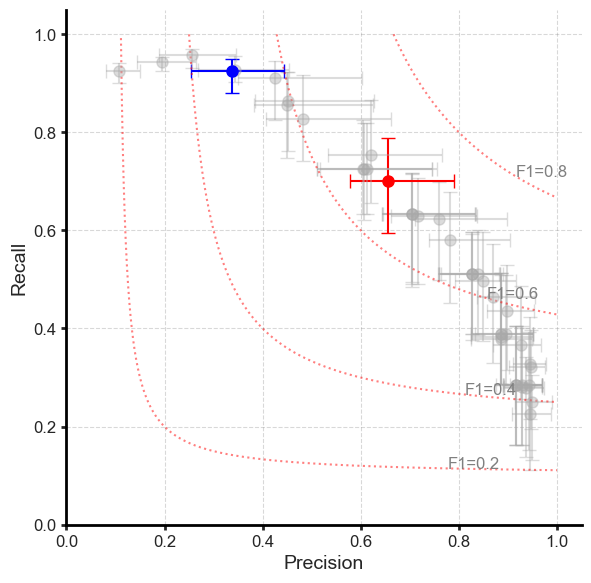

In [17]:
def plot_precision_recall_curve(df, thresholds_to_include=None, fall_offs_to_include=None):
    # Filter for specific buffer size if needed, e.g., buffer=6

    thresholds_to_include = thresholds_to_include if thresholds_to_include is not None else sorted(df["Threshold"].unique())
    fall_offs_to_include = fall_offs_to_include if fall_offs_to_include is not None else sorted(df["Fall_off"].unique())
    mask= (df["Threshold"].isin(thresholds_to_include)) & (df["Fall_off"].isin(fall_offs_to_include))
    df_subset=df[mask].copy()
    
    df_subset["Group"] = df_subset["Threshold"].astype(str) + "_" + df_subset["Fall_off"].astype(str)
    group_order = sorted(df_subset["Group"].unique(), key=lambda x: ((x.split("_")[0]), x.split("_")[1]))
    
    # Calculate median (50%), 25%, and 75% quantiles
    summary = df_subset.groupby("Group")[["Precision", "Recall"]].quantile([0.25, 0.5, 0.75]) # one row per threshold per quantile
    display(summary.head())
    # Sort index appropriately for plotting logic
    # Unstack to get columns like (Precision, 0.5), (Precision, 0.25) ...
    summary = summary.unstack(level=1) # create multi-index columns # Metric, Quantile
    # display(summary.head()  )
    # Extract Medians as the central point
    means = summary.xs(0.5, axis=1, level=1).sort_index(ascending=False) # Extract median values (Threshold, Metric)
    # display(means.head())

    # Calculate IQR errors:
    # lower_err = median - Q1
    # upper_err = Q3 - median
    q1 = summary.xs(0.25, axis=1, level=1).sort_index(ascending=False) # Extract Q1 values (Threshold, Metric)
    q3 = summary.xs(0.75, axis=1, level=1).sort_index(ascending=False) # Extract Q3 values (Threshold, Metric)
    
    # Define errors for errorbar plot (shape: 2xN for each point [lower, upper])
    # Precision Errors
    prec_err_lower = means["Precision"] - q1["Precision"]
    prec_err_upper = q3["Precision"] - means["Precision"]
    
    # Recall Errors
    rec_err_lower = means["Recall"] - q1["Recall"]
    rec_err_upper = q3["Recall"] - means["Recall"]
    
    thresholds = means.index.values

    fig,ax=plt.subplots(figsize=(6,6))
    
    # Plot the line connecting the medians
    # ax.plot(means["Precision"], means["Recall"], 'k--', alpha=0.5)
    
    # Plot points with IQR error bars
    sorted_thresholds = sorted(thresholds)
    # Use same viridis colors as cell 8
    # colors = get_threshold_colors(sorted_thresholds)
    colors=["darkgray"]*len(sorted_thresholds)
    color_map = {th: col for th, col in zip(sorted_thresholds, colors)}
    
    for i, th in enumerate(thresholds):
        # print(th)
        alpha=0.4
        if th=="6.0_4.0":
            print("Found optimal threshold, highlighting in red")
            color_map[th] = 'red'  # Highlight this point in red
            alpha=1.0
        elif th=="4.0_1.0":
            print("Found reference threshold, highlighting in blue")
            color_map[th] = 'blue'  # Highlight this point in blue
            alpha=1.0
        # Prepare error arrays (needs to be sequence of shape (2, 1) or scalar if symmetric, but here asymmetric)
        xerr = [[prec_err_lower[th]], [prec_err_upper[th]]]
        yerr = [[rec_err_lower[th]], [rec_err_upper[th]]]
        
        ax.errorbar(means.loc[th, "Precision"], means.loc[th, "Recall"], 
                     xerr=xerr, 
                     yerr=yerr, 
                     fmt='o', color=color_map[th], 
                     capsize=5, label=f'{th}', markersize=8, alpha=alpha)

    # Add F1 isolines for reference
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0, 1, 10000)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        valid = (y > 0) & (y < 1)
        ax.plot(x[valid], y[valid], 'r:', linewidth=1.5,alpha=0.5)
        if any(valid):
            ax.text(x[valid][int(len(x[valid])*0.75)], y[valid][int(len(y[valid])*0.75)], f"F1={f1}", color='gray', fontsize=12)

    ax.set_xlabel("Precision",fontsize=14)
    ax.set_ylabel("Recall",fontsize=14)
    ax.set_xlim(0,1.05)
    ax.set_ylim(0,1.05)
    
    # Set Aspect Ratio to be Equal
    ax.set_aspect('equal', adjustable='box')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2,bottom=True, left=True)
    ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.3)
    
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threshold")
    plt.tight_layout()
    plt.show()  
    return fig,ax
fig,ax = plot_precision_recall_curve(df, thresholds_to_include=sorted(df["Threshold"].unique()), fall_offs_to_include=[1,2,3,4,5,6,7,8,9])